In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

Exercise 1

1. Use the following dataset to generate a regression dataset:<br>
X = (2 - 3*np.random.normal(0, 1,200)).reshape(200,1)<br>
y = 0.5*X^3 - 2*X^2 + X + np.random.normal(-3, 3,200).reshape(-l,l) .<br>
Apply polynomial regression algorithm and plot the predictions of the model<br>
for X_test = np.linspace(â€”5, 10, 200).reshape (200, 1).

In [ ]:
X = (2 - 3 * np.random.normal(0,1,200)).reshape(200,1)
y = 0.5 * np.power(X,3) - 2 * np.power(X,2) + X + np.random.normal(-3,3,200).reshape(-1,1)

In [ ]:
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])

[5.92230181]


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([-3.15293829]), array([[ 1.02638429, -2.0191921 ,  0.50094809]]))

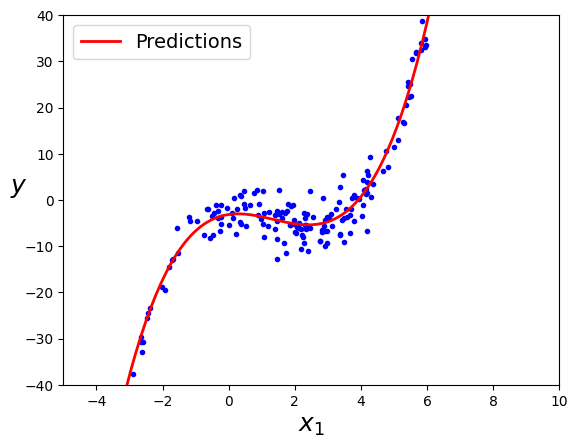

In [ ]:
X_new = np.linspace(-5, 10, 200).reshape(200,1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-5, 10, -40, 40])
plt.show()

Exercise 2

2. Use the following dataset to generate a regression dataset:<br>
X = 3*np.random.rand(150, 1)<br>
y = -2 + + np.random.randn(150, 1).<br>
Perform ridge regression using mini-batch gradient descent. Use a learning<br>
rate of 0.06, 15 epochs and a batch size of 10. Set lambda to 0.01. Plot the<br>
prediction of the model and print the model weights.

In [3]:
X = 3 * np.random.rand(150,1)
y = -2 + 3 * X + np.random.randn(150,1)
X_1 = np.c_[np.ones((150, 1)), X] # add x0 = 1 to each instance

In [4]:
np.random.seed(42)
eta = 0.06
n_epochs = 15
batch_size = 10
alpha = 0.01
n = 150 # size of dataset
w = np.random.randn(2,1)  # random initialization

In [5]:
for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(n)
    X_1_shuffled = X_1[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for i in range(0, n, batch_size):
        xi = X_1_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        gradients = 1/batch_size * xi.T.dot(xi.dot(w) - yi) + alpha * w
        w = w - eta * gradients
w

array([[-1.55756697],
       [ 2.70599084]])

In [6]:
X_new = np.linspace(0, 3, 150).reshape(150, 1)

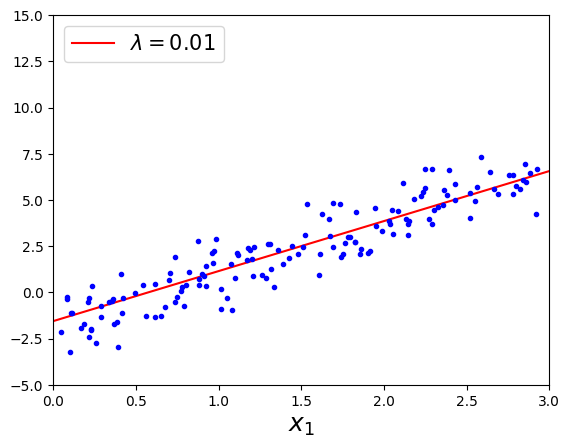

In [12]:
X_new_b = np.c_[np.ones((150, 1)), X_new]
y_new_reg = X_new_b.dot(w)
plt.plot(X_new, y_new_reg, ("r-"), label=r"$\lambda = {}$".format(alpha))
plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left", fontsize=15)
plt.xlabel("$x_1$", fontsize=18)
plt.axis([0, 3, -5, 15])
plt.show()

Exercise 3

3. Use the digits dataset in order to apply the softmax regression algorithm.<br>
Load the dataset by calling the load_digits function. Split the data such<br>
that the test split is 35% of the initial dataset. Print the shapes of training<br>
and testing dataset. Train the algorithm for 700 epochs, use the "lbfgs"<br>
solver and set the hyperparameter C to 5. After the model is trained, print<br>
the test set accuracy. Also predict and print the probabilities that the model<br>
assigned to the ten classes for the second example in the test set.

In [ ]:
digits_dataset = datasets.load_digits()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(digits_dataset['data'], digits_dataset['target'], random_state=0, test_size=0.35)

In [ ]:
X_train.shape, y_train.shape

((1168, 64), (1168,))

In [ ]:
X_test.shape, y_test.shape

((629, 64), (629,))

In [ ]:
softmax_reg = LogisticRegression(max_iter=700, multi_class="multinomial", solver="lbfgs", C=5, random_state=42)
softmax_reg.fit(X_train, y_train)
softmax_reg.score(X_test, y_test)

c:\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9570747217806042

In [ ]:
softmax_reg.predict_proba([X_test[1]])

array([[6.68964197e-10, 2.00459197e-09, 1.75182884e-07, 7.23313160e-15,
        8.89827088e-04, 2.96714312e-07, 1.26827641e-09, 4.89687142e-12,
        9.99109697e-01, 1.25054199e-10]])